Goal: compare average diurnal cycle of dT/dz with depth for different surface IDs

Code largely from Raven_surface_comparisons.ipynb

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy import interpolate
import scipy.signal
from datetime import datetime as dt
import cmocean
import datetime
from matplotlib.dates import DateFormatter
import glob
# import math
# from astropy.convolution import convolve
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib as mpl
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import pandas as pd
import csv
myFmt = mdates.DateFormatter('%m-%d')

from ICECAPS_support_functions import *

### Write more functions

In [3]:
def datetimes_to_seconds(dates_in):
    """ convert datetime objects to seconds since 1970/1/1 (arbitrary)
    dates_in should be a list or array of datetime object
    """
    seconds_out = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in dates_in])
    return seconds_out

In [4]:
def open_simba_sfc_file(file_version):
    acceptable_file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2',
                               'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0']

    if file_version not in acceptable_file_versions:
        print("Please choose of these versions: ", acceptable_file_versions)
        return
        
    sfc_fname = f'Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_{file_version[:11]}.csv'

    df = pd.read_csv('/home/asledd/ICECAPS/'+sfc_fname)
    simba_sfc_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['datetime'].values])       
    simba_sfc_in = df['surface [cm]'].values

    return simba_sfc_dates, simba_sfc_in

In [5]:
def open_corrected_simba_temps(file_version):
    acceptable_file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2',
                               'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0']

    if file_version not in acceptable_file_versions:
        print("Please choose of these versions: ", acceptable_file_versions)
        return 

    if file_version=='v2_20250723':
        fn = '/home/asledd/ICECAPS/firnprofile_solar-correction_rolling-variance-max-sfc_created_20250722.nc'
    elif 'v4' in file_version:
        fn = f'/home/asledd/ICECAPS/firnprofile_solar-correction_rolling-variance-max-sfc-{file_version}_created_20250726.nc'
    else:
        fn = f'/home/asledd/ICECAPS/firnprofile_solar-correction_rolling-variance-max-sfc-{file_version}_created_20250725.nc'
    season_data_solar = {}
    
    varnames = ['temp','initial_height','time']
    fdic = load_netcdf(fn, varnames)
    
    fdic['dates'] = np.asarray([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(s)) for s in fdic['time']])
    season_data_solar['seconds'] = fdic['time']
    
    for varout, varin in zip(['temperature','dates','height'],['temp', 'dates','initial_height']):
        season_data_solar[varout] = fdic[varin]
    

    return season_data_solar

In [6]:
def interpolate_and_mask(var_data, var_secs, goal_secs):
    """
    interpolate var_data to have same time steps as goal_secs; mask data outside of bounds
    """
    f_var = interpolate.interp1d(var_secs, var_data, fill_value=-999, bounds_error=False)
    interped_var = f_var(goal_secs)
    interped_var = np.ma.masked_equal(interped_var, -999)
    return interped_var

In [7]:
def make_temps_rel_to_sfc(heights_rel_to_simba, temps_rel_to_simba, sfc_rel_to_simba):

    depths_rel_to_sfc = np.repeat(heights_rel_to_simba.copy()[np.newaxis,:], temps_rel_to_simba.shape[0], axis=0)
    sfc_2d = np.ma.repeat(sfc_rel_to_simba[:,np.newaxis], temps_rel_to_simba.shape[1], axis=1)
    depths_rel_to_sfc = depths_rel_to_sfc-sfc_2d


    temporary_temp = np.ma.masked_where(depths_rel_to_sfc>0, temps_rel_to_simba) # temporary temperature that's only at or below the surface

    m = 100. # I don't remember why this is 100!
    temps_rel_to_sfc = []
    
    for i in range(temporary_temp.shape[0]):
        temp_i = temporary_temp[i,:-1]
        sub_t = temp_i[~temp_i.mask]
    
        sub_t_filled = np.ma.concatenate( (sub_t, np.full(int(m-sub_t.count()), -999 )) )
        temps_rel_to_sfc.append(sub_t_filled)
        
    temps_rel_to_sfc = np.ma.masked_equal(temps_rel_to_sfc, -999)

    ## new height variable that decreases downward
    sub_depths = np.arange(0,temps_rel_to_sfc.shape[1])
    sub_depths *= -2

    return sub_depths, np.ma.masked_invalid(temps_rel_to_sfc)

In [8]:
def get_simba_time_of_day(dates_in):
    simba_hours = np.array([d.hour for d in dates_in])
    simba_mins = np.array([d.minute for d in dates_in])
    
    ## time of day
    simba_tod = simba_hours+simba_mins/60.
    
    return simba_tod

In [9]:
def get_diurnal_cycle(dates_in, data_in, stat='mean'):
    
    tod = get_simba_time_of_day(dates_in)
    if stat=='mean':
        daily_data_out = np.array([data_in[np.where(tod==t)[0],:].mean(axis=0) for t in np.unique(tod)])
    elif stat=='std':
        daily_data_out = np.array([data_in[np.where(tod==t)[0],:].std(axis=0) for t in np.unique(tod)])

    return daily_data_out

In [10]:
def load_uncorrected_simba():
    simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
    fn = 'firnprofile-combined-corrected-at38.sled.level2.beta.15min.20240517-20240821_created_June26_2025.nc'
    
    season_data_unc = {}
    if 'firnprofile-combined-corrected' in fn:
        varnames = ['temperature','initial_height','time']
        fdic = load_netcdf(simba_filepath+fn, varnames)
    else:
        varnames = ['temp','initial_height','time']
        fdic = load_netcdf(fn, varnames)
    
    if 'firnprofile-combined-corrected' in fn:
        fstart_time = datetime.datetime.strptime(fdic['time_unit'], 'minutes since %Y-%m-%d')
        fdic['dates'] = np.asarray([fstart_time+datetime.timedelta(minutes=int(m)) for m in fdic['time']])
    else:    
        fdic['dates'] = np.asarray([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(s)) for s in fdic['time']])
    season_data_unc['seconds'] = fdic['time']
    
    for var in ['temperature','dates','initial_height']:
        if var=='temperature' and fn=='firnprofile_maxheight_solar-correction_created_20250417.nc':
            season_data_unc['temperature'] = fdic['temp']
        else:
            season_data_unc[var] = fdic[var]
    
    if 'firnprofile-combined-corrected' in fn:
        season_data_unc['height'] = season_data_unc['initial_height'][::-1]
        season_data_unc['temperature'] = season_data_unc['temperature'][:,::-1]
    else:
        season_data_unc['height'] = season_data_unc['initial_height']
        
    return season_data_unc

### Start loading in data and plotting


#### testing functions work

In [109]:
fversion = 'v2_20250723'

In [112]:
simba_data = open_corrected_simba_temps(fversion)
sfc_dates, sfc_data = open_simba_sfc_file(fversion)

sfc_seconds = datetimes_to_seconds(sfc_dates)
simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                     
simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

In [113]:
depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])

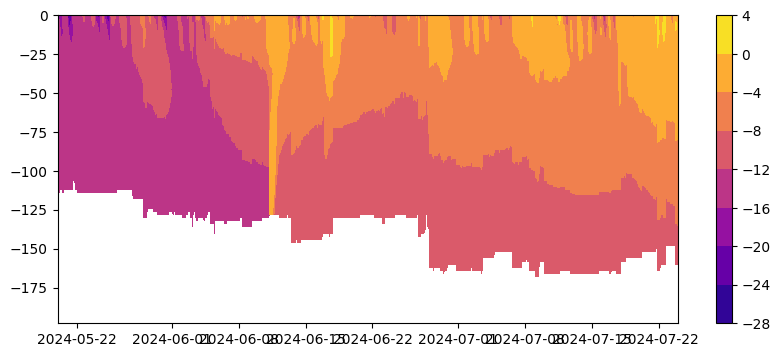

In [114]:
fig, axs = plt.subplots(1, figsize=(10,4))

cb = plt.contourf(simba_data['dates'], depth_rel_sfc, np.swapaxes(temps_rel_sfc,0,1), cmap='plasma')
# plt.plot(simba_dates, simba_sfc-6.,  c='k')
plt.colorbar(cb)

# plt.xlim(dt(2024,6,8),dt(2024,6,15))
plt.show()

In [115]:
dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

In [116]:
avg_diurnal_dTdz = get_diurnal_cycle(simba_data['dates'], dTdz_rel_sfc)
avg_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc)
std_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc, stat='std')

In [117]:
plt_tod = get_simba_time_of_day(simba_data['dates'])

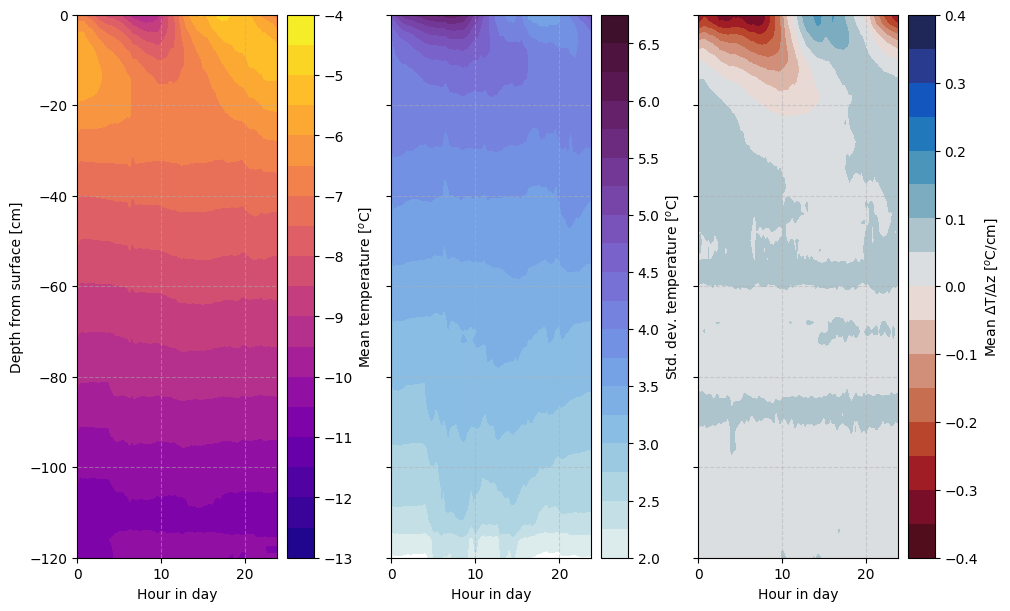

In [119]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]', 'Mean $\Delta$T/$\Delta$z [$^o$C/cm]']
levels = [np.arange(-13,-3.6,.5), np.arange(2,7,.25), np.arange(-.4,.41,.05)]
cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.balance_r]

for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_T, std_diurnal_T, avg_diurnal_dTdz])):
    cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])
    plt.colorbar(cb, label=cbar_labels[i], ax=ax)

    ax.set_ylim(-120,0)
    
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

axs[0].set_ylabel('Depth from surface [cm]')
# plt.tight_layout()
plt.show()

#### Loop over all the files I'm interested in

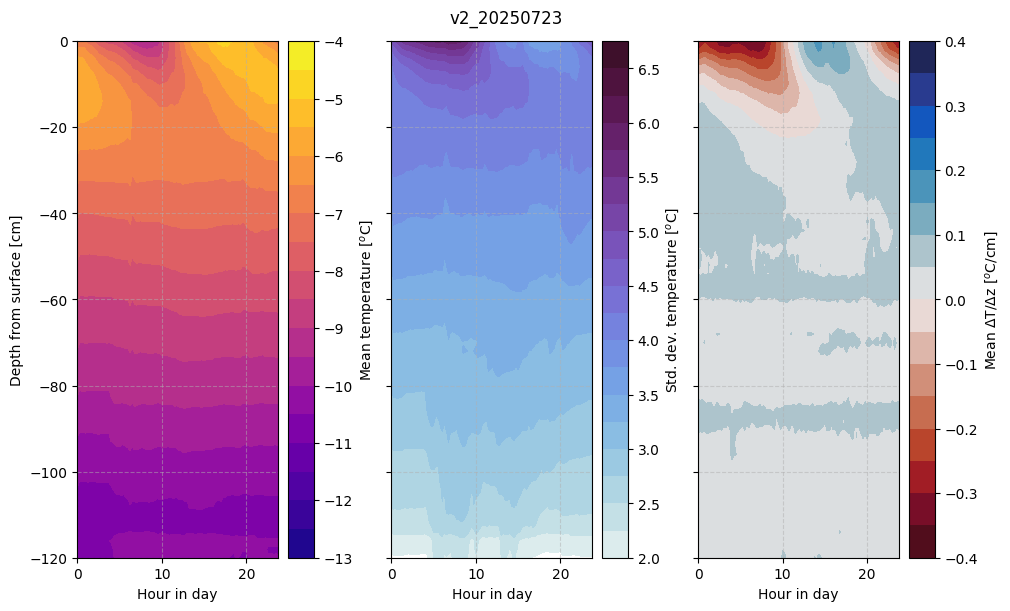

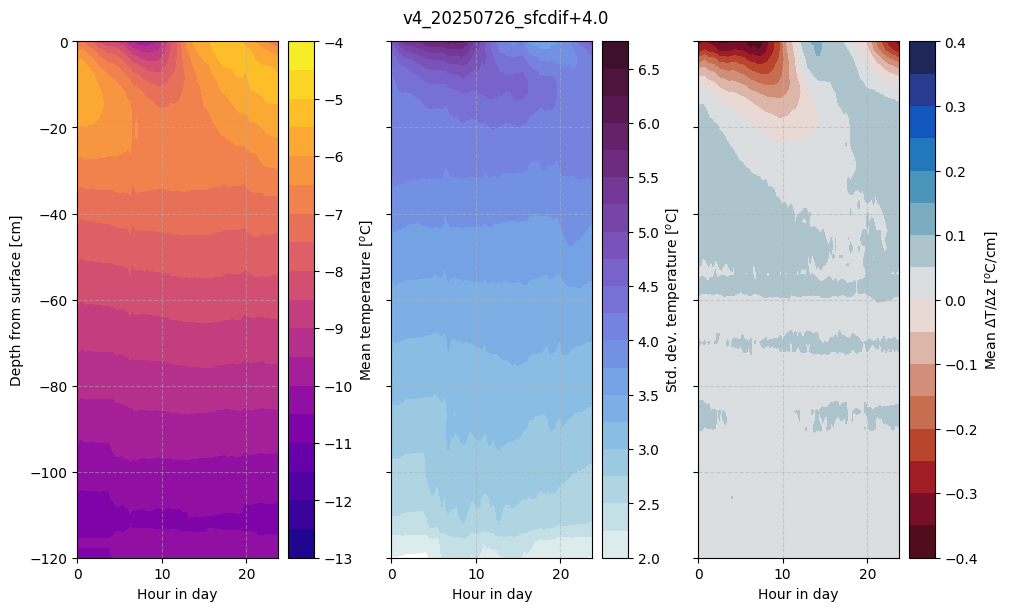

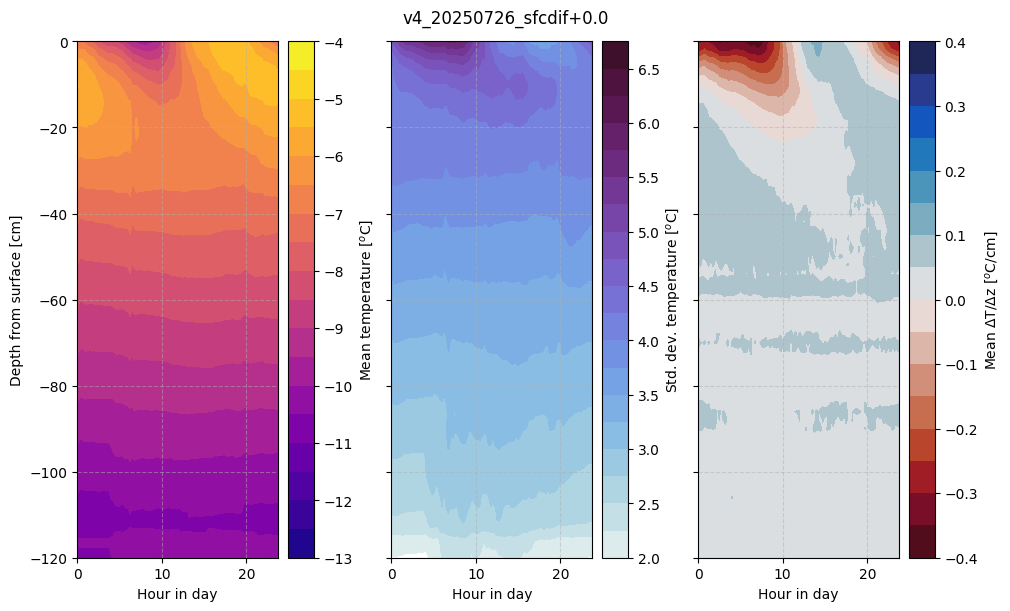

In [11]:
# file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2']
file_versions = ['v2_20250723', 'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0']

for fversion in file_versions:
    simba_data = open_corrected_simba_temps(fversion)
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    
    sfc_seconds = datetimes_to_seconds(sfc_dates)
    simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                         
    simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

    depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])
    dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

    avg_diurnal_dTdz = get_diurnal_cycle(simba_data['dates'], dTdz_rel_sfc)
    avg_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc)
    std_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc, stat='std')

    plt_tod = get_simba_time_of_day(simba_data['dates'])


    fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)
    
    cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]', 'Mean $\Delta$T/$\Delta$z [$^o$C/cm]']
    levels = [np.arange(-13,-3.6,.5), np.arange(2,7,.25), np.arange(-.4,.41,.05)]
    cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.balance_r]
    
    for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_T, std_diurnal_T, avg_diurnal_dTdz])):
        cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])
        plt.colorbar(cb, label=cbar_labels[i], ax=ax)
    
        ax.set_ylim(-120,0)
        
        ax.set_xlabel('Hour in day')
        ax.grid(alpha=.5, ls='--')
    
    axs[0].set_ylabel('Depth from surface [cm]')
    fig.suptitle(fversion)
    plt.show()

### Does melty/not have a bigger impact now?

In [12]:
def get_gpr_melt():
    df = pd.read_csv('/psd3data/arctic/sledd/Melt_Index_despiked_GPR_Raven2024.csv')
    
    gpr_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['date'].values])       
    gpr_melt = df['Melt_Index_Normal'].values
    return {'dates':gpr_dates, 'melt':gpr_melt}

In [13]:
def get_gpr_melt_dates(gpr_melt_data, simba_dates, melt_threshold=0.8):

    melty_dates = np.ma.masked_where(gpr_melt_data<melt_threshold, simba_dates)
    melty_day_mn = np.unique([' '.join((str(d.day), str(d.month))) for d in melty_dates[~melty_dates.mask]])
    all_day_mn = np.asarray([' '.join((str(d.day), str(d.month))) for d in simba_dates])
    
    ## inefficient but whatever
    simba_melty_indices = np.zeros(simba_dates.shape)
    
    for md in melty_day_mn:    
        simba_melty_indices[np.where(all_day_mn==md)] = 1

    return simba_melty_indices

In [14]:
def get_subset_dTdz_cycle(melt_indices, data_in, melt_or_dry, dates_in):
    
    melt_masking = {'melt':1, 'dry':0}

    if melt_or_dry not in melt_masking.keys():
        print('Give melt or dry to determine subset')
        return

    melt_val = melt_masking[melt_or_dry]
    
    data_in_subset = dTdz_rel_sfc[np.where(melt_indices==melt_val)[0],:]
    simba_dates_subset = dates_in[np.where(melt_indices==melt_val)[0]]
    
    daily_avgs_subset = get_diurnal_cycle(simba_dates_subset, data_in_subset, stat='mean')
    return daily_avgs_subset


In [15]:
gpr_data = get_gpr_melt()
gpr_seconds = datetimes_to_seconds(gpr_data['dates'])
gpr_melt_idx = interpolate_and_mask(gpr_data['melt'], gpr_seconds, simba_seconds)

In [16]:
simba_melty_idx = get_gpr_melt_dates(gpr_melt_idx, simba_data['dates'])

In [17]:
daily_avgs_dTdz_dry = get_subset_dTdz_cycle(simba_melty_idx, avg_diurnal_dTdz, 'dry', simba_data['dates'])
daily_avgs_dTdz_melty = get_subset_dTdz_cycle(simba_melty_idx, avg_diurnal_dTdz, 'melt', simba_data['dates'])

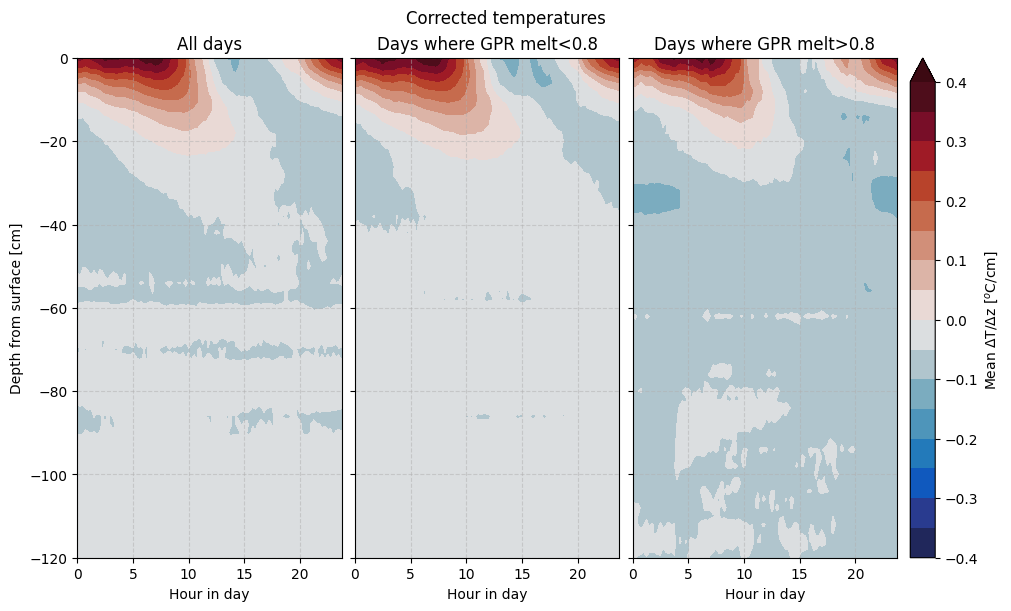

In [18]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

subtitles = ['All days', 'Days where GPR melt<0.8', 'Days where GPR melt>0.8']


for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_dTdz, daily_avgs_dTdz_dry, daily_avgs_dTdz_melty])):
    cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var*-1.,0,1), levels=np.arange(-.4,.41,.05), 
                     cmap=cmocean.cm.balance, extend='max')
    

    ax.set_ylim(-120,0)
    ax.set_title(subtitles[i])
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

plt.colorbar(cb, label='Mean $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[-1])

axs[0].set_ylabel('Depth from surface [cm]')
fig.suptitle('Corrected temperatures')
# plt.tight_layout()
plt.show()

/tmp/ipykernel_362336/2128157274.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_362336/2128157274.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_362336/2128157274.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


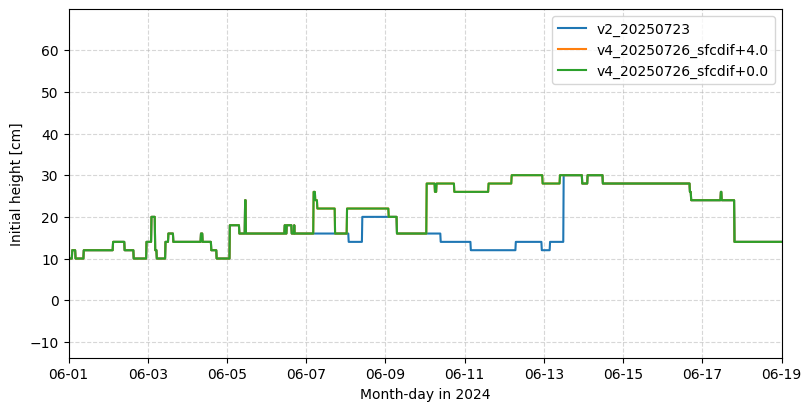

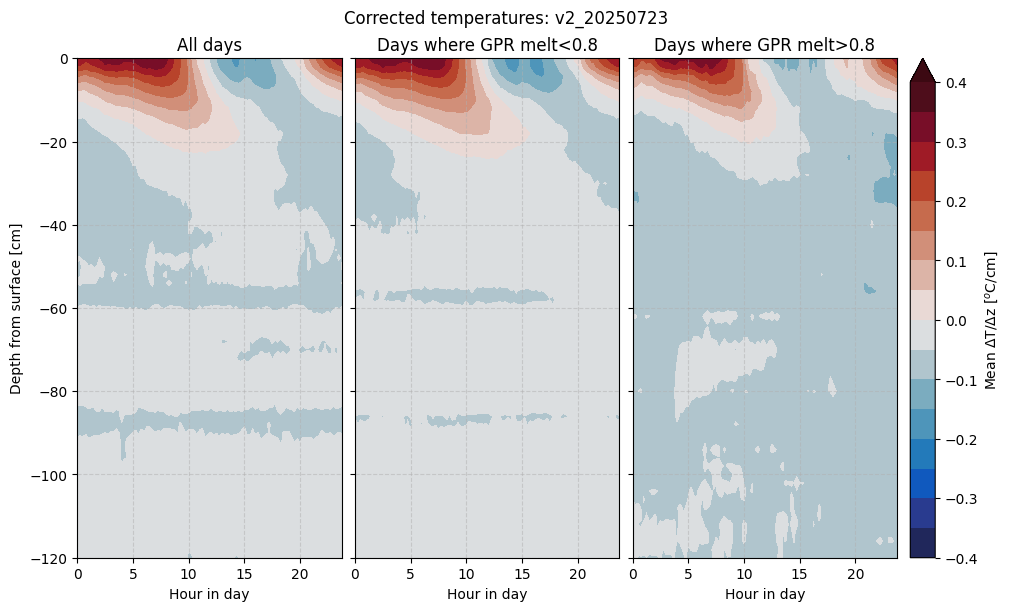

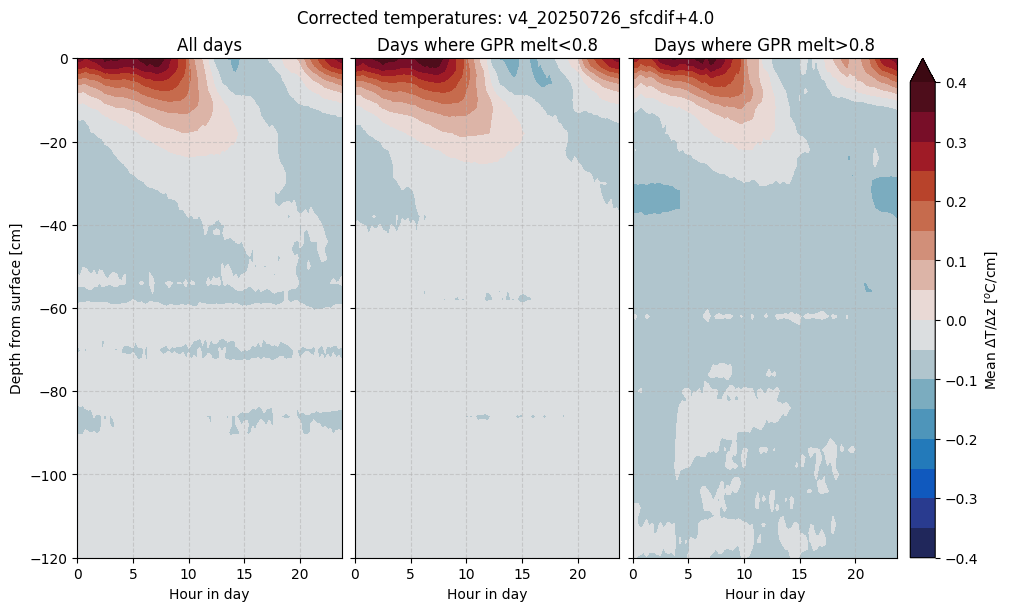

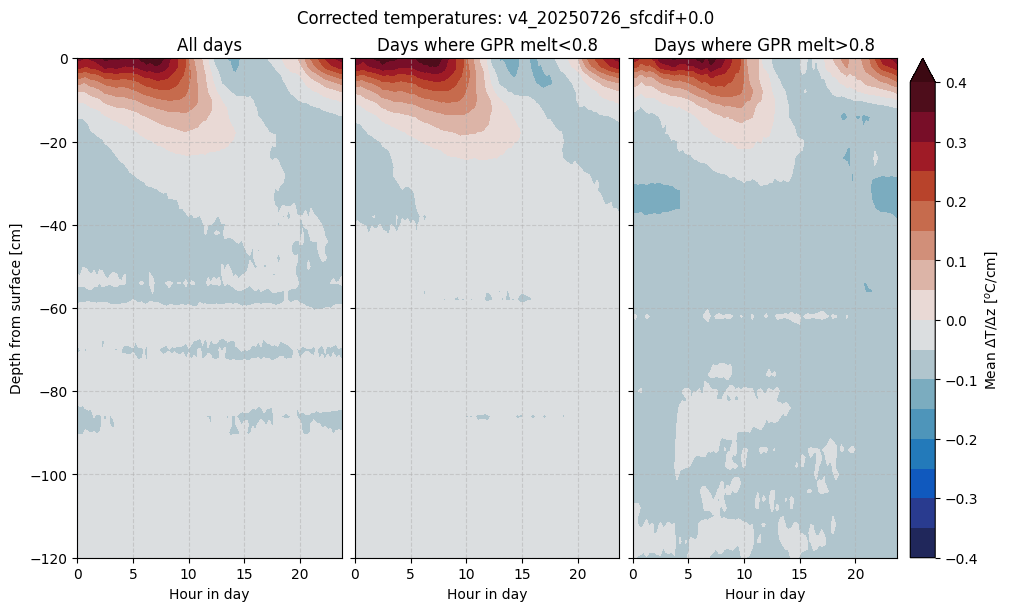

In [19]:
# file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2']
file_versions = ['v2_20250723', 'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0']

fig_sfcs, ax_sfcs = plt.subplots(1, figsize=(8,4), constrained_layout=True)

for fversion in file_versions:
    simba_data = open_corrected_simba_temps(fversion)
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)

    ax_sfcs.plot(sfc_dates, sfc_data, label=fversion)
    
    sfc_seconds = datetimes_to_seconds(sfc_dates)
    simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                         
    simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

    depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])
    dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

    avg_diurnal_dTdz = get_diurnal_cycle(simba_data['dates'], dTdz_rel_sfc)
    avg_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc)
    std_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc, stat='std')

    plt_tod = get_simba_time_of_day(simba_data['dates'])


    simba_melty_idx = get_gpr_melt_dates(gpr_melt_idx, simba_data['dates'])
    daily_avgs_dTdz_dry = get_subset_dTdz_cycle(simba_melty_idx, avg_diurnal_dTdz, 'dry', simba_data['dates'])
    daily_avgs_dTdz_melty = get_subset_dTdz_cycle(simba_melty_idx, avg_diurnal_dTdz, 'melt', simba_data['dates'])
    
    fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)
    
    subtitles = ['All days', 'Days where GPR melt<0.8', 'Days where GPR melt>0.8']
    
    
    for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_dTdz, daily_avgs_dTdz_dry, daily_avgs_dTdz_melty])):
        cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var*-1.,0,1), levels=np.arange(-.4,.41,.05), 
                         cmap=cmocean.cm.balance, extend='max')
        
    
        ax.set_ylim(-120,0)
        ax.set_title(subtitles[i])
        ax.set_xlabel('Hour in day')
        ax.grid(alpha=.5, ls='--')
    
    plt.colorbar(cb, label='Mean $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[-1])
    
    axs[0].set_ylabel('Depth from surface [cm]')
    fig.suptitle(f'Corrected temperatures: {fversion}')
    # plt.tight_layout()
    fig.show()

ax_sfcs.set_xlim(datetime.datetime(2024,6,1),datetime.datetime(2024,6,19))
ax_sfcs.xaxis.set_major_formatter(myFmt)
ax_sfcs.set_xlabel('Month-day in 2024')
ax_sfcs.grid(alpha=.5, ls='--')
ax_sfcs.set_ylabel('Initial height [cm]')
ax_sfcs.legend(loc='best')
plt.show()

#### compare surface heights to uncorrected dT/dz (and dT/dt?)

In [24]:
def load_ogre_surfaces():
    ogre_surface_out = {}

    for ogre in ['rav1_south','rav2_origin','rav3_west']:
        df = pd.read_csv('/psd3data/arctic/sledd/Raven_OGRE/'+ogre+'.csv')
        
        ogre_date = np.array([dt.strptime(d, '%m/%d/%y %H:%M') for d in df['Datetime'].values])       
        ogre_sfc = df[' Average Ant. Height [m]'].values
        ogre_surface_out[ogre] = {'dates':ogre_date, 'sfc':ogre_sfc}
    return ogre_surface_out

In [21]:
uncorrected_simba_data = load_uncorrected_simba()

In [22]:
uncorr_dTdz = np.gradient(uncorrected_simba_data['temperature'], uncorrected_simba_data['height'], axis=1)

uncorr_seconds = datetimes_to_seconds(uncorrected_simba_data['dates'])
uncorr_dTdt = np.gradient(uncorrected_simba_data['temperature'], uncorr_seconds, axis=0)

In [23]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)

In [25]:
ogre_surface = load_ogre_surfaces()

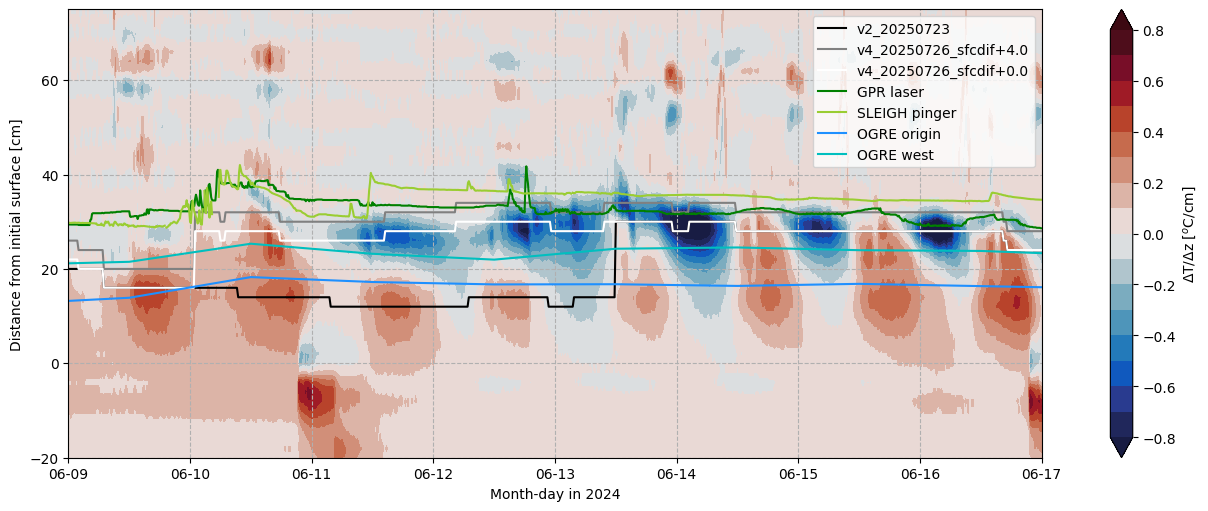

In [34]:


fig, ax = plt.subplots(1, figsize=(12,5), constrained_layout=True, sharex=False)

cmap = plt.cm.RdPu
# cmap = cmocean.cm.amp
cb = ax.contourf(uncorrected_simba_data['dates'], uncorrected_simba_data['height'], np.swapaxes(uncorr_dTdz,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.8,.81,.1), extend='both')

plt.colorbar(cb, ax=ax, label='$\Delta$T/$\Delta$z [$^o$C/cm]')

ax.grid(ls='--')

for fversion, c in zip(file_versions,['k','gray','w']):
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    if '+4' in fversion:
        sfc_data += 4.
    ax.plot(sfc_dates, sfc_data, label=fversion, c=c)

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='green')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='yellowgreen')

for ogre, c in zip(['rav2_origin','rav3_west'],['dodgerblue', 'c']):
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)

ax.legend(loc='upper right')

ax.set_ylabel('Distance from initial surface [cm]')
ax.set_ylim(-20, 75)

ax.set_xlim(datetime.datetime(2024,6,9),datetime.datetime(2024,6,17))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
# plt.savefig('/home/asledd/ICECAPS/keff_retrieval/Raven_dtdz-flux-profile-timeseries_skinT_3level-smoothing-window.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_uncorrected_T_sfc-comparisons.png', dpi=300)

plt.show()